# Logistic Regression from Scratch

## Objective

Implement Logistic Regression from scratch using NumPy for binary image classification.

## Topics

- Data preprocessing
- Parameter initialization
- Forward propagation
- Sigmoid activation
- Binary cross-entropy loss
- Gradient computation
- Gradient descent optimization
- Prediction
- Model evaluation

In [10]:
!pip install h5py opencv-python 

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
    --------------------------------------- 1.0/44.0 MB 12.5 MB/s eta 0:00:04
   ------ --------------------------------- 7.3/44.0 MB 25.2 MB/s eta 0:00:02
   ------------ --------------------------- 13.6/44.0 MB 28.5 MB/s eta 0:00:02
   ----------------- ---------------------- 19.7/44.0 MB 28.2 MB/s eta 0:00:01
   ----------------------- ---------------- 26.2/44.0 MB 29.1 MB/s eta 0:00:01
   ----------------------------- ---------- 32.2/44.0 MB 29.7 MB/s eta 0:00:01
   ----------------------------------- ---- 39.1/44.0 MB 29.9 MB/s eta 0:00:01
   ---------------------------------------  43.8/44.0 MB 29.9 MB/s eta 0:00:01
   ---------------------------------------- 44.0/44.0 MB 27.7 MB/s  0:00:01


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from sklearn.decomposition import PCA

In [12]:
import sys, os
sys.path.append(os.path.abspath(".."))
from utilities.utilities import *

In [13]:
def initialize_parameters  (X):
    W = np.zeros((X.shape[1], 1))
    b = 0
    return (W, b)

In [14]:
def model(X, W, b):
    Z = X.dot(W) + b
    A = 1 / (1 + np.exp(-Z))
    return A

In [15]:
def logloss(A, y):
    #Good practice to avoid calculating logarithms at 0
    epsilon = 1e-15
    return 1 / len(y) * np.sum(-y * np.log(A+epsilon) - (1 - y) * np.log(1 - A+epsilon))

In [16]:
def compute_gradients(A,X,y):
    dW = 1 / len(y) * np.dot(X.T, A - y)
    db = 1 / len(y) * np.sum(A - y)
    return (dW, db)

In [17]:
def update_parameters(W, b, dw, db, lr):
    W = W - lr * dw
    b = b - lr * db
    return W, b

In [18]:
def predict(X, W, b):
    A = model(X, W, b)
    return (A >= 0.5).astype(int)

In [19]:
def preprocess(X):
    X = X.reshape(X.shape[0], -1)
    X = X/255.0
    return X

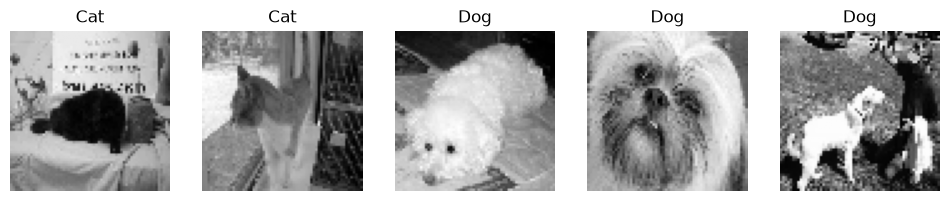

[0. 1.]


In [24]:
X_train, y_train, X_test, y_test = load_data()

indices = np.random.choice(len(X_train), size=5, replace=False)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[idx], cmap="gray")  
    plt.title("Dog" if y_train[idx] == 1 else "Cat")  
    plt.axis("off")
plt.show()    
X_train = preprocess(X_train)
X_test = preprocess(X_test)


In [30]:
def logistic_regression(X_train, y_train, X_test, y_test, lr=0.01, nb_iter=1000):
    W, b = initialize_parameters (X_train)
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for i in tqdm(range(nb_iter)):
        # Forward train
        A_train = model(X_train, W, b)
        train_losses.append(logloss(A_train, y_train))
        y_pred_train = (A_train > 0.5).astype(int)
        train_accs.append(accuracy_score(y_train, y_pred_train))

        # Forward test
        A_test = model(X_test, W, b)
        y_pred = predict(X_test, W, b)
        test_losses.append(logloss(A_test, y_test))
        y_pred_test = (A_test > 0.5).astype(int)
        test_accs.append(accuracy_score(y_test, y_pred_test))

        # Gradients + update
        dW, db = compute_gradients(A_train, X_train, y_train)
        W, b = update_parameters(W, b, dW, db, lr)


    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(test_accs, label="Test Accuracy")
    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    return W, b


100%|██████████| 2000/2000 [00:24<00:00, 82.09it/s] 


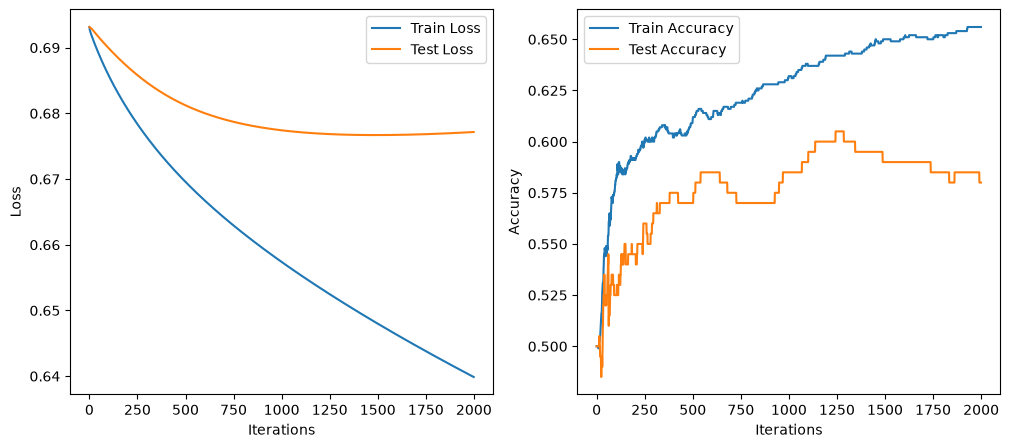

Test Accuracy : 0.58


In [31]:
W, b = logistic_regression(X_train, y_train, X_test, y_test, lr=0.001, nb_iter=2000)
y_pred = predict(X_test, W, b)
print("Test Accuracy :", accuracy_score(y_test, y_pred))


Logistic Regression was successfully implemented from scratch using NumPy and achieved a **58.5% test accuracy**.
Unlike the Perceptron example, this image classification task is more challenging, and a linear model has limited capacity to capture the complex patterns present in the data.